In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
import fsps
import sedpy
import prospect
import emcee
import dynesty


# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [2]:
grapes = tab[(tab['halpha_flux']>0)&(tab['oiii5007_ew']>100)]
grapes.sort('oiii5007_flux')
grapes[-2]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d04m12pt825s-44d21m10pt642s,38.070229166666664,-44.35295611111111,0.40292640529351553,66.73403958150307,0,0,0,8.969458542722732,0.0071141320617926825,8.150940159413311,0.0002622770955946467,8.162632124545151,0.2310792637281556,52.167125686054774,11.366223970474508,0.282,rxj0232m44,22567.1412073046,354.6168687556022,128.08897740369298,5.497713979981577,5006.834015829306,1.9980823399660776,47.58586696794032,6909.889981192684,933.7871419981336,19.408720732766298,7.277460935748094,4958.849131583009,1.7838306402540278,42.122918614158394,9815.98386042128,333.47237723449535,31.03228480758622,5.3098464551879445,3726.2293091856905,2.2526145560741524,73.15631758124707,11807.609335391948,374.7664395449063,37.404139444223546,5.967367573421555,3729.12559

In [37]:
# fig, ax = pf.create_plot()
# axes = [ax]
candidate = grapes[-2]
cluster = candidate['name']
print(cluster)
loc = '../../../cubes/'+cluster+'_COMBINED_CUBE_MED_FINAL.fits'
with fits.open(loc) as hdul:
    cx,cy = (hdul[1].header['CRVAL1'],hdul[1].header['CRVAL2'])
    cent = SkyCoord(cx,cy, unit = u.deg)

galloc = SkyCoord(candidate['ra'], candidate['dec'], unit=u.deg)
cube_ift = ift.museCube(loc, cent.ra.deg,cent.dec.deg)
cluster = Cube(loc)
linefits = cube_ift.pick_target(galloc,candidate['z'],0.7,plot=False)

spectrum = cube_ift.spectra.get(list(cube_ift.spectra.keys())[0])
rest_spectrum = cube_ift.rest_spectra.get(list(cube_ift.spectra.keys())[0])

freq = np.linspace(rest_spectrum.get_start(), rest_spectrum.get_end(), rest_spectrum.shape[0])
redshift = cube_ift.ex_table['z'][0]

wave_rest = rest_spectrum.wave.coord()  # Angstroms
flux = rest_spectrum.data*1e-20            # erg/s/cm^2/Angstrom (check units)
flux_unc = np.sqrt(rest_spectrum.var*1e-20)   # Get std deviation from variance

# --- 3. Convert Flux Units to Maggies ---
# Prospector's models operate in "maggies", a linear flux unit.
d_lum = cosmo.luminosity_distance(redshift).to(u.cm).value 
c = speedoflight.to(u.AA / u.s).value

flux_nu = flux * (wave_rest**2 / c)
unc_nu = flux_unc * (wave_rest**2 / c)
flux_jy = flux_nu / 1e-23
unc_jy = unc_nu / 1e-23
maggies = (flux_jy / 3631.0) 
maggies_unc = (unc_jy / 3631.0)
mask = (wave_rest > 3700) & (wave_rest < 7000)

rxj0232m44


The Formula

  The conversion is given by:


  $F_\nu (\text{Jy}) = \frac{F_\lambda \cdot \lambda^2}{c} \times 10^{23}$

  Where:


   * $F_\nu$ is the flux density in Janskys (Jy).
   * $F_\lambda$ is the flux density in erg s⁻¹ cm⁻² Å⁻¹.
   * $\lambda$ is the wavelength in Angstroms (Å).
   * $c$ is the speed of light in Å s⁻¹ ($c \approx 3 \times 10^{18}$ Å/s).


  Plugging in the value for the speed of light, the formula simplifies to:


  $F_\nu (\text{Jy}) \approx (3.336 \times 10^4) \cdot F_\lambda \cdot \lambda^2$

  ---

  Derivation


   1. Fundamental Relation: The energy received per unit area per unit time is the same whether you measure it per unit wavelength or per unit frequency. Therefore, we can state:
      $F_\nu d\nu = F_\lambda d\lambda$


   2. Relate Frequency and Wavelength: Start with the basic equation $ \nu = c / \lambda $. To find the relationship between $d\nu$ and $d\lambda$, we differentiate $\nu$ with respect to $\lambda$:
      $\frac{d\nu}{d\lambda} = -\frac{c}{\lambda^2}$


      We only care about the magnitude for the conversion, so we can ignore the negative sign (which just indicates that frequency decreases as wavelength increases).
      $d\nu = \frac{c}{\lambda^2} d\lambda$


   3. Substitute: Now substitute this expression for $d\nu$ back into our fundamental relation:
      $F_\nu \left( \frac{c}{\lambda^2} d\lambda \right) = F_\lambda d\lambda$


      Cancel out the $d\lambda$ term from both sides to get the physical conversion:
      $F_\nu = F_\lambda \frac{\lambda^2}{c}$


   4. Unit Conversion: This gives us $F_\nu$ in units of erg s⁻¹ cm⁻² Hz⁻¹. The final step is to convert this to Janskys.
       * The definition of a Jansky is:
          $1 \text{ Jy} = 10^{-26} \text{ W m}^{-2} \text{ Hz}^{-1}$
       * Since $1 \text{ W} = 10^7 \text{ erg s}^{-1}$ and $1 \text{ m}^2 = 10^4 \text{ cm}^2$, we can convert the Jansky to cgs units:
          $1 \text{ Jy} = 10^{-26} \frac{10^7 \text{ erg s}^{-1}}{10^4 \text{ cm}^2} \text{ Hz}^{-1} = 10^{-23} \text{ erg s}^{-1} \text{ cm}^{-2} \text{ Hz}^{-1}$


      Therefore, to convert our result for $F_\nu$ from erg s⁻¹ cm⁻² Hz⁻¹ to Janskys, we must divide by $10^{-23}$ (or multiply by $10^{23}$).


      $F_\nu (\text{in Jy}) = \left( F_\lambda \frac{\lambda^2}{c} \right) \times 10^{23}$


In [38]:
maggies

masked_array(data=[5.5096207065568795e-11, 4.8531372444697005e-11,
                   5.7148734992677743e-11, ..., -5.65780106701517e-10,
                   -7.686083959030631e-11, -4.108328873917378e-11],
             mask=[False, False, False, ..., False, False, False],
       fill_value=1e+20)

In [39]:
def build_obs(snr=10, ldist=10.0, **extras):
    """Build a dictionary of observational data.  In this example 
    the data consist of photometry for a single nearby dwarf galaxy 
    from Johnson et al. 2013.
    
    :param snr:
        The S/N to assign to the photometry, since none are reported 
        in Johnson et al. 2013
        
    :param ldist:
        The luminosity distance to assume for translating absolute magnitudes 
        into apparent magnitudes.
        
    :returns obs:
        A dictionary of observational data to use in the fit.
    """
    from prospect.utils.obsutils import fix_obs
    import sedpy

    # The obs dictionary, empty for now
    obs = {}

    # These are the names of the relevant filters, 
    # in the same order as the photometric data (see below)
    galex = ['galex_FUV', 'galex_NUV']
    spitzer = ['spitzer_irac_ch'+n for n in ['1','2','3','4']]
    sdss = ['sdss_{0}0'.format(b) for b in ['u','g','r','i','z']]
    filternames = galex + sdss + spitzer
    # And here we instantiate the `Filter()` objects using methods in `sedpy`,
    # and put the resultinf list of Filter objects in the "filters" key of the `obs` dictionary
    obs["filters"] = sedpy.observate.load_filters(filternames)
    # obs["filters"] = None


    # Now we store the measured fluxes for a single object, **in the same order as "filters"**
    # In this example we use a row of absolute AB magnitudes from Johnson et al. 2013 (NGC4163)
    # We then turn them into apparent magnitudes based on the supplied `ldist` meta-parameter.
    # You could also, e.g. read from a catalog.
    # The units of the fluxes need to be maggies (Jy/3631) so we will do the conversion here too.
    M_AB = np.array([-11.93, -12.37, -13.37, -14.22, -14.61, -14.86, 
                     -14.94, -14.09, -13.62, -13.23, -12.78])
    dm = 25 + 5.0 * np.log10(ldist)
    mags = M_AB + dm
    obs["maggies"] = 10**(-0.4*mags)
    # obs["maggies"] = None

    # And now we store the uncertainties (again in units of maggies)
    # In this example we are going to fudge the uncertainties based on the supplied `snr` meta-parameter.
    obs["maggies_unc"] = (1./snr) * obs["maggies"]
    # obs["maggies_unc"] = None

    # Now we need a mask, which says which flux values to consider in the likelihood.
    # IMPORTANT: the mask is *True* for values that you *want* to fit, 
    # and *False* for values you want to ignore.  Here we ignore the spitzer bands.
    obs["phot_mask"] = np.array([False for f in obs["filters"]])
    # obs["phot_mask"] = np.array(['spitzer' not in f.name for f in obs["filters"]])

    # obs["phot_mask"] = None

    # This is an array of effective wavelengths for each of the filters.  
    # It is not necessary, but it can be useful for plotting so we store it here as a convenience
    # obs["phot_wave"] = np.array([f.wave_effective for f in obs["filters"]])
    obs["phot_wave"] = None


    # We do not have a spectrum, so we set some required elements of the obs dictionary to None.
    # (this would be a vector of vacuum wavelengths in angstroms)
    obs["wavelength"] = wave_rest
    # (this would be the spectrum in units of maggies)
    obs["spectrum"] = maggies.data
    # (spectral uncertainties are given here)
    obs['unc'] = maggies_unc
    # (again, to ignore a particular wavelength set the value of the 
    #  corresponding elemnt of the mask to *False*)
    obs['mask'] = np.ones_like(wave_rest).astype(bool)

    # This function ensures all required keys are present in the obs dictionary,
    # adding default values if necessary
    obs = fix_obs(obs)

    return obs

In [40]:
run_params = {}
run_params["snr"] = 10
run_params["ldist"] = (d_lum*u.cm).to(u.Mpc).value
obs = build_obs(**run_params)

In [41]:
mass_param = {"name": "mass",
              # The mass parameter here is a scalar, so it has N=1
              "N": 1,
              # We will be fitting for the mass, so it is a free parameter
              "isfree": True,
              # This is the initial value. For fixed parameters this is the
              # value that will always be used. 
              "init": 1e8,
              # This sets the prior probability for the parameter
              "prior": priors.LogUniform(mini=1e6, maxi=1e12),
              # this sets the initial dispersion to use when generating 
              # clouds of emcee "walkers".  It is not required, but can be very helpful.
              "init_disp": 1e6, 
              # this sets the minimum dispersion to use when generating 
              #clouds of emcee "walkers".  It is not required, but can be useful if 
              # burn-in rounds leave the walker distribution too narrow for some reason.
              "disp_floor": 1e6, 
              # This is not required, but can be helpful
              "units": "solar masses formed",
              }

In [42]:
def build_model(object_redshift=None, ldist=10.0, fixed_metallicity=None, add_duste=False, 
                **extras):
    """Build a prospect.models.SedModel object
    
    :param object_redshift: (optional, default: None)
        If given, produce spectra and observed frame photometry appropriate 
        for this redshift. Otherwise, the redshift will be zero.
        
    :param ldist: (optional, default: 10)
        The luminosity distance (in Mpc) for the model.  Spectra and observed 
        frame (apparent) photometry will be appropriate for this luminosity distance.
        
    :param fixed_metallicity: (optional, default: None)
        If given, fix the model metallicity (:math:`log(Z/Z_sun)`) to the given value.
        
    :param add_duste: (optional, default: False)
        If `True`, add dust emission and associated (fixed) parameters to the model.
        
    :returns model:
        An instance of prospect.models.SedModel
    """
    from prospect.models.sedmodel import SedModel
    from prospect.models.templates import TemplateLibrary
    from prospect.models import priors

    # Get (a copy of) one of the prepackaged model set dictionaries.
    # This is, somewhat confusingly, a dictionary of dictionaries, keyed by parameter name
    model_params = TemplateLibrary["parametric_sfh"]
    
   # Now add the lumdist parameter by hand as another entry in the dictionary.
   # This will control the distance since we are setting the redshift to zero.  
   # In `build_obs` above we used a distance of 10Mpc to convert from absolute to apparent magnitudes, 
   # so we use that here too, since the `maggies` are appropriate for that distance.
    model_params["lumdist"] = {"N": 1, "isfree": False, "init": ldist, "units":"Mpc"}
    
    # Let's make some changes to initial values appropriate for our objects and data
    model_params["zred"]["init"] = 0.0
    model_params["dust2"]["init"] = 0.05
    model_params["logzsol"]["init"] = -0.5
    model_params["tage"]["init"] = 13.
    model_params["mass"]["init"] = 1e8
    
    # These are dwarf galaxies, so lets also adjust the metallicity prior,
    # the tau parameter upward, and the mass prior downward
    model_params["dust2"]["prior"] = priors.TopHat(mini=0.0, maxi=2.0)
    model_params["tau"]["prior"] = priors.LogUniform(mini=1e-1, maxi=1e2)
    model_params["mass"]["prior"] = priors.LogUniform(mini=1e6, maxi=1e10)

    # If we are going to be using emcee, it is useful to provide a 
    # minimum scale for the cloud of walkers (the default is 0.1)
    model_params["mass"]["disp_floor"] = 1e6
    model_params["tau"]["disp_floor"] = 1.0
    model_params["tage"]["disp_floor"] = 1.0
    
    # Change the model parameter specifications based on some keyword arguments
    if fixed_metallicity is not None:
        # make it a fixed parameter
        model_params["logzsol"]["isfree"] = False
        #And use value supplied by fixed_metallicity keyword
        model_params["logzsol"]['init'] = fixed_metallicity 

    if object_redshift is not None:
        # make sure zred is fixed
        model_params["zred"]['isfree'] = False
        # And set the value to the object_redshift keyword
        model_params["zred"]['init'] = object_redshift

    if add_duste:
        # Add dust emission (with fixed dust SED parameters)
        # Since `model_params` is a dictionary of parameter specifications, 
        # and `TemplateLibrary` returns dictionaries of parameter specifications, 
        # we can just update `model_params` with the parameters described in the 
        # pre-packaged `dust_emission` parameter set.
        model_params.update(TemplateLibrary["dust_emission"])
        
    # Now instantiate the model object using this dictionary of parameter specifications
    model = SedModel(model_params)

    return model


run_params["object_redshift"] = redshift
run_params["fixed_metallicity"] = None
run_params["add_duste"] = True
run_params["ldist"] = (d_lum*u.cm).to(u.Mpc).value

In [43]:
model = build_model(**run_params)
print(model)
print("\nInitial free parameter vector theta:\n  {}\n".format(model.theta))
print("Initial parameter dictionary:\n{}".format(model.params))

:::::::
<class 'prospect.models.sedmodel.SedModel'>

Free Parameters: (name: prior) 
-----------
  mass: <class 'prospect.models.priors.LogUniform'>(mini=1000000.0,maxi=10000000000.0)
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-2,maxi=0.19)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=2.0)
  tage: <class 'prospect.models.priors.TopHat'>(mini=0.001,maxi=13.8)
  tau: <class 'prospect.models.priors.LogUniform'>(mini=0.1,maxi=100.0)

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: [0.40292641] 
  sfh: [4] 
  imf_type: [2] 
  dust_type: [0] 
  lumdist: [2259.49593322] 
  add_dust_emission: [ True] 
  duste_umin: [1.] 
  duste_qpah: [4.] 
  duste_gamma: [0.001] 

Initial free parameter vector theta:
  [ 1.0e+08 -5.0e-01  5.0e-02  1.3e+01  1.0e+00]

Initial parameter dictionary:
{'zred': array([0.40292641]), 'mass': array([1.e+08]), 'logzsol': array([-0.5]), 'dust2': array([0.05]), 'sfh': array([4]), 'tage': array([13.]), 'imf_type': array([2

In [44]:
def build_sps(zcontinuous=1, **extras):
    """
    :param zcontinuous: 
        A vlue of 1 insures that we use interpolation between SSPs to 
        have a continuous metallicity parameter (`logzsol`)
        See python-FSPS documentation for details
    """
    from prospect.sources import CSPSpecBasis
    sps = CSPSpecBasis(zcontinuous=zcontinuous)
    return sps

run_params["zcontinuous"] = 1

In [45]:
sps = build_sps(**run_params)
# help(sps.get_spectrum)

In [46]:
from prospect.likelihood import lnlike_spec, lnlike_phot, write_log

verbose = False
def lnprobfn(theta, model=None, obs=None, sps=None, 
             nested=False, verbose=verbose):
    """
    Given a parameter vector, a model, a dictionary of observational 
    data, and an sps object, return the ln of the posterior. 
    """

    # Calculate prior probability and exit if not within prior
    # Also if doing nested sampling, do not include the basic priors, 
    # since the drawing method includes the prior probability
    lnp_prior = model.prior_product(theta, nested=nested)
    if not np.isfinite(lnp_prior):
        return -np.infty
        
    # Generate "mean" model
    spec, phot, mfrac = model.mean_model(theta, obs, sps=sps)
 
    # Calculate likelihoods
    lnp_spec = lnlike_spec(spec, obs=obs)
    lnp_phot = lnlike_phot(phot, obs=obs)

    return lnp_prior + lnp_phot + lnp_spec

run_params["verbose"] = verbose

In [47]:
from prospect.likelihood import chi_spec, chi_phot
def chivecfn(theta):
    """A version of lnprobfn that returns the simple uncertainty 
    normalized residual instead of the log-posterior, for use with 
    least-squares optimization methods like Levenburg-Marquardt.
    
    It's important to note that the returned chi vector does not 
    include the prior probability.
    """
    lnp_prior = model.prior_product(theta)
    if not np.isfinite(lnp_prior):
        return np.zeros(model.ndim) - np.infty

    # Generate mean model
    try:
        spec, phot, x = model.mean_model(theta, obs, sps=sps)
    except(ValueError):
        return np.zeros(model.ndim) - np.infty

    chispec = chi_spec(spec, obs)
    chiphot = chi_phot(phot, obs)
    return np.concatenate([chispec, chiphot])


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_19339/307396032.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


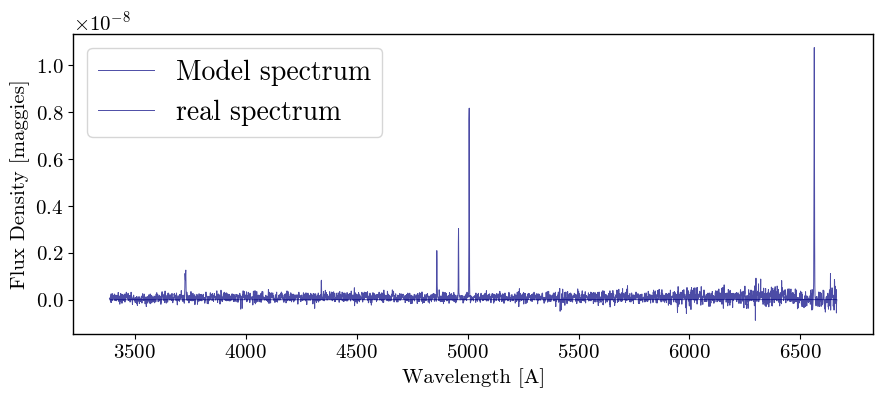

In [54]:
# Generate the model SED at the initial value of theta
theta = model.theta.copy()
initial_spec, initial_phot, initial_mfrac = model.sed(theta, obs=obs, sps=sps)
title_text = ','.join(["{}={}".format(p, model.params[p][0]) 
                       for p in model.free_params])

a = 1.0 + model.params.get('zred', 0.0) # cosmological redshifting
# photometric effective wavelengths
wphot = obs["phot_wave"]
# spectroscopic wavelengths
if obs["wavelength"] is None:
    # *restframe* spectral wavelengths, since obs["wavelength"] is None
    wspec = sps.wavelengths
    wspec *= a #redshift them
else:
    wspec = obs["wavelength"]

# establish bounds
xmin, xmax = np.min(wspec)*0.8, np.max(wspec)/0.8
temp = np.interp(np.linspace(xmin,xmax,10000), wspec, initial_spec)
ymin, ymax = temp.min()*0.8, temp.max()/0.4
fig,ax=pf.create_plot((8,3))

# plot model + data
ax.plot(wspec, initial_spec, label='Model spectrum', 
       lw=0.7, color='navy', alpha=0.7)
ax.plot(wspec, maggies, label='real spectrum', 
       lw=0.7, color='navy', alpha=0.7)
# ax.errorbar(wphot, initial_phot, label='Model photometry', 
#          marker='s',markersize=10, alpha=0.8, ls='', lw=3,
#          markerfacecolor='none', markeredgecolor='blue', 
#          markeredgewidth=3)
# ax.errorbar(wphot, obs['maggies'], yerr=obs['maggies_unc'], 
#          label='Observed photometry',
#          marker='o', markersize=10, alpha=0.8, ls='', lw=3,
#          ecolor='red', markerfacecolor='none', markeredgecolor='red', 
#          markeredgewidth=3)
# ax.title(title_text)

# plot Filters
# for f in obs['filters']:
#     w, t = f.wavelength.copy(), f.transmission.copy()
#     t = t / t.max()
#     t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
#     ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
# ax.set_xlim([xmin, xmax])
# ax.set_ylim([ymin, ymax])
ax.legend(loc='best', fontsize=20)
plt.tight_layout()

In [55]:
from prospect.fitting import lnprobfn

In [56]:
# Here we will run all our building functions
obs = build_obs(**run_params)
sps = build_sps(**run_params)
model = build_model(**run_params)
# For fsps based sources it is useful to 
# know which stellar isochrone and spectral library
# we are using
print(sps.ssp.libraries)

(b'mist', b'miles', b'DL07')


In [57]:
from prospect.fitting import fit_model

In [58]:
# --- start minimization ----
run_params["dynesty"] = False
run_params["emcee"] = False
run_params["optimize"] = True
run_params["min_method"] = 'lm'
# We'll start minimization from "nmin" separate places, 
# the first based on the current values of each parameter and the 
# rest drawn from the prior.  Starting from these extra draws 
# can guard against local minima, or problems caused by 
# starting at the edge of a prior (e.g. dust2=0.0)
run_params["nmin"] = 2

output = fit_model(obs, model, sps, lnprobfn=lnprobfn, **run_params)

print("Done optmization in {}s".format(output["optimization"][1]))

Done optmization in 73.80722689628601s


[ 1.80055121e+08 -1.99999381e+00  2.76507149e-01  2.40003871e+00
  8.06191713e+01]
1
[ 1.80055121e+08 -1.99999381e+00  2.76507149e-01  2.40003871e+00
  8.06191713e+01]


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_19339/3494983016.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


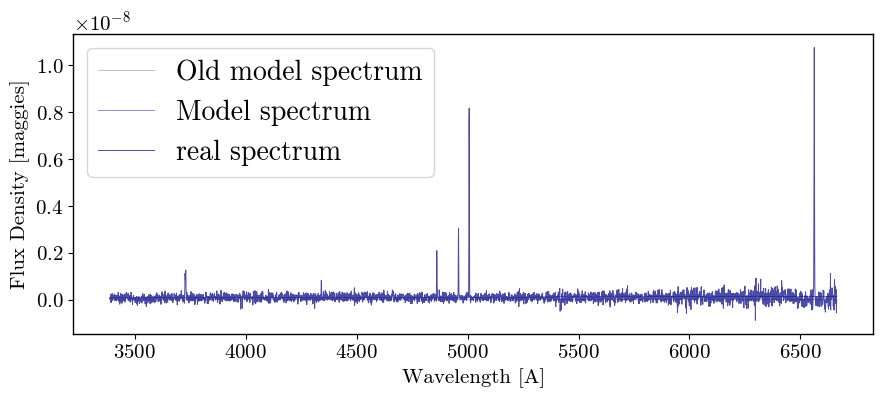

In [64]:
print(model.theta)
(results, topt) = output["optimization"]
# Find which of the minimizations gave the best result, 
# and use the parameter vector for that minimization
ind_best = np.argmin([r.cost for r in results])
print(ind_best)
theta_best = results[ind_best].x.copy()
print(theta_best)

# generate model
prediction = model.mean_model(theta_best, obs=obs, sps=sps)
pspec, pphot, pfrac = prediction

# figure= plt.figure(figsize=(16,8))
fig, ax = pf.create_plot((8,3))

# plot Data, best fit model, and old models
ax.plot(wspec, initial_spec, label='Old model spectrum',
       lw=0.7, color='gray', alpha=0.5)
# ax.errorbar(wphot, initial_phot, label='Old model Photometry', 
#          marker='s', markersize=10, alpha=0.6, ls='', lw=3, 
#          markerfacecolor='none', markeredgecolor='gray', 
#          markeredgewidth=3)
ax.plot(wspec, pspec, label='Model spectrum', 
       lw=0.7, color='slateblue', alpha=0.7)
ax.plot(wspec, maggies, label='real spectrum', 
       lw=0.7, color='navy', alpha=0.7)
# ax.errorbar(wphot, pphot, label='Model photometry', 
#          marker='s', markersize=10, alpha=0.8, ls='', lw=3,
#          markerfacecolor='none', markeredgecolor='slateblue', 
#          markeredgewidth=3)
# ax.errorbar(wphot, obs['maggies'], yerr=obs['maggies_unc'],
#          label='Observed photometry', 
#          marker='o', markersize=10, alpha=0.8, ls='', lw=3, 
#          ecolor='tomato', markerfacecolor='none', markeredgecolor='tomato', 
#          markeredgewidth=3)

# plot filter transmission curves
for f in obs['filters']:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
#     ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# Prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
# ax.set_xlim([xmin, xmax])
# ax.set_ylim([ymin, ymax])
ax.legend(loc='best', fontsize=20)
plt.tight_layout()

In [ ]:
model

In [ ]:
sps

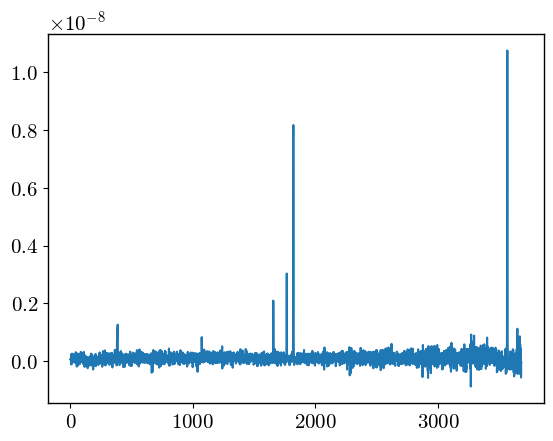

In [51]:
plt.plot(obs['spectrum'])